<a href="https://colab.research.google.com/github/https-deeplearning-ai/tensorflow-1-public/blob/master/C2/W4/ungraded_lab/C2_W4_Lab_1_multi_class_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-class Classifier

In this example, you will look at how to build a model to distinguish between more than two classes. The code will be similar to the ones you've been using before with a few key changes in the model and in the training parameters. Let's dive in!


**IMPORTANT NOTE:** This notebook is designed to run as a Colab. Running the notebook on your local machine might result in some of the code blocks throwing errors.

## Download and Prepare the Dataset

You will be using the [Rock-Paper-Scissors dataset](https://www.tensorflow.org/datasets/catalog/rock_paper_scissors), a gallery of hands images in Rock, Paper, and Scissors poses.

In [3]:
# Download the train set
!wget https://storage.googleapis.com/learning-datasets/rps.zip

!wget https://storage.googleapis.com/learning-datasets/rps-validation.zip

# Download the test set
!wget https://storage.googleapis.com/learning-datasets/rps-test-set.zip

--2025-12-04 08:32:36--  https://storage.googleapis.com/learning-datasets/rps.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.10.207, 142.251.12.207, 64.233.170.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.10.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 200682221 (191M) [application/zip]
Saving to: ‘rps.zip.1’

rps.zip.1           100%[===================>] 191.38M  23.8MB/s    in 9.6s    

2025-12-04 08:32:47 (19.9 MB/s) - ‘rps.zip.1’ saved [200682221/200682221]

--2025-12-04 08:32:47--  https://storage.googleapis.com/learning-datasets/rps-validation.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.10.207, 142.251.12.207, 64.233.170.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.10.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6623597 (6.3M) [application/zip]
Saving to: ‘rps-validation.zip.1’

rps-validation

In [4]:
import zipfile

# Extract the archive
local_zip = './rps.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('tmp/rps-train')
zip_ref.close()

local_zip = './rps-validation.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('tmp/rps-validation')
zip_ref.close()

local_zip = './rps-test-set.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('tmp/rps-test')
zip_ref.close()

As usual, you will assign the directory names into variables and look at the filenames as a sanity check.

In [5]:
import os

base_dir = 'tmp/rps-train/rps'

rock_dir = os.path.join(base_dir, 'rock')
paper_dir = os.path.join(base_dir, 'paper')
scissors_dir = os.path.join(base_dir, 'scissors')

print('total training rock images:', len(os.listdir(rock_dir)))
print('total training paper images:', len(os.listdir(paper_dir)))
print('total training scissors images:', len(os.listdir(scissors_dir)))

rock_files = os.listdir(rock_dir)
print(rock_files[:10])

paper_files = os.listdir(paper_dir)
print(paper_files[:10])

scissors_files = os.listdir(scissors_dir)
print(scissors_files[:10])

total training rock images: 840
total training paper images: 840
total training scissors images: 840
['rock02-067.png', 'rock07-k03-018.png', 'rock01-100.png', 'rock04-090.png', 'rock04-007.png', 'rock05ck01-002.png', 'rock04-081.png', 'rock05ck01-076.png', 'rock04-082.png', 'rock02-034.png']
['paper01-117.png', 'paper07-085.png', 'paper02-024.png', 'paper01-107.png', 'paper02-105.png', 'paper02-083.png', 'paper07-052.png', 'paper03-113.png', 'paper01-013.png', 'paper04-088.png']
['testscissors01-037.png', 'testscissors02-085.png', 'testscissors03-006.png', 'testscissors01-064.png', 'scissors02-080.png', 'testscissors02-081.png', 'testscissors02-040.png', 'scissors01-079.png', 'testscissors03-002.png', 'scissors03-118.png']


You can also inspect some of the images to see the variety in your model inputs.

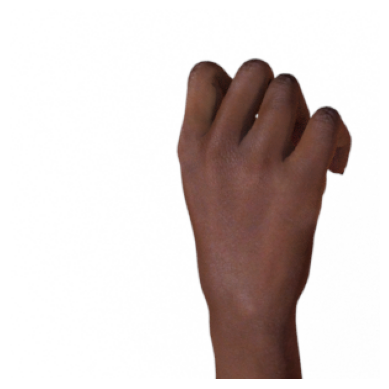

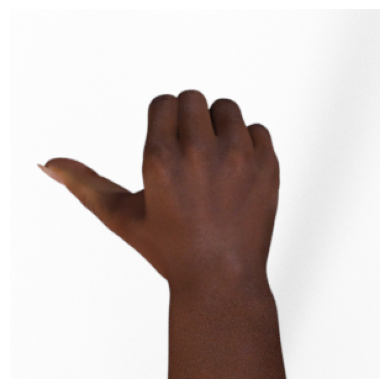

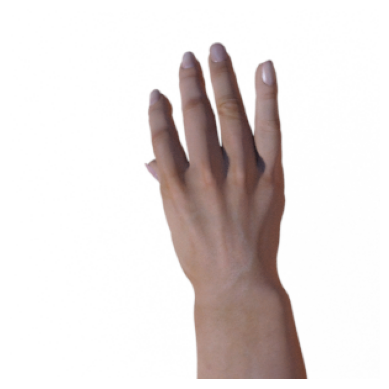

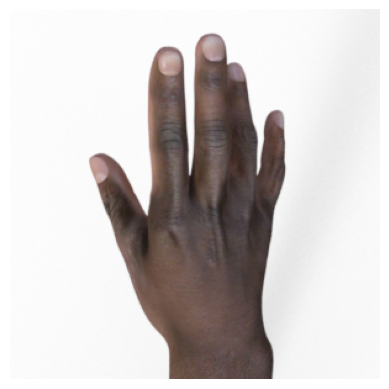

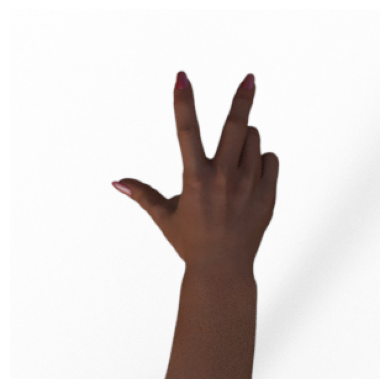

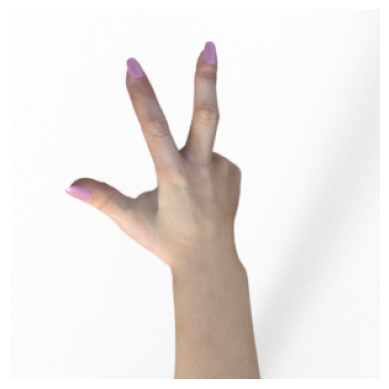

In [6]:
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

pic_index = 2

next_rock = [os.path.join(rock_dir, fname)
                for fname in rock_files[pic_index-2:pic_index]]
next_paper = [os.path.join(paper_dir, fname)
                for fname in paper_files[pic_index-2:pic_index]]
next_scissors = [os.path.join(scissors_dir, fname)
                for fname in scissors_files[pic_index-2:pic_index]]

for i, img_path in enumerate(next_rock+next_paper+next_scissors):
  img = mpimg.imread(img_path)
  plt.imshow(img)
  plt.axis('Off')
  plt.show()

## Build the model

You will then build your CNN. You will use 4 convolution layers with 64-64-128-128 filters then append a `Dropout` layer to avoid overfitting and some Dense layers for the classification. The output layer would be a 3-neuron dense layer activated by [Softmax](https://www.tensorflow.org/api_docs/python/tf/nn/softmax). You've seen this before when you were training with Fashion MNIST. It scales your output to a set of probabilities that add up to 1. The order of this 3-neuron output would be `paper`-`rock`-`scissors` (e.g. a `[0.8 0.2 0.0]` output means the model is prediciting 80% probability for paper and 20% probability for rock.

You can examine the architecture with `model.summary()` below.

In [7]:
import tensorflow as tf

model = tf.keras.models.Sequential([
    # Note the input shape is the desired size of the image 150x150 with 3 bytes color
    # This is the first convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    # The second convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The third convolution
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The fourth convolution
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # Flatten the results to feed into a DNN
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),
    # 512 neuron hidden layer
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

# Print the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,473,475 (13.25 MB)

 Trainable params: 3,473,475 (13.25 MB)

 Non-trainable params: 0 (0.00 B)

You will then compile the model. The key change here is the `loss` function. Whereas before you were using `binary_crossentropy` for 2 classes, you will change it to [categorical_crossentropy](https://keras.io/api/losses/probabilistic_losses/#categoricalcrossentropy-function) to extend it to more classes.

In [8]:
# Set the training parameters
model.compile(loss = 'categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

## Prepare the ImageDataGenerator

You will prepare the generators as before. You will set the training set up for data augmentation so it can mimick other poses that the model needs to learn.

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TRAINING_DIR = "tmp/rps-train/rps"
training_datagen = ImageDataGenerator(
      rescale = 1./255,
	    rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest')

VALIDATION_DIR = "tmp/rps-test/rps-test-set"
validation_datagen = ImageDataGenerator(rescale = 1./255)

train_generator = training_datagen.flow_from_directory(
	TRAINING_DIR,
	target_size=(150,150),
	class_mode='categorical',
  batch_size=126
)

validation_generator = validation_datagen.flow_from_directory(
	VALIDATION_DIR,
	target_size=(150,150),
	class_mode='categorical',
  batch_size=126
)

Found 2520 images belonging to 3 classes.
Found 372 images belonging to 3 classes.


## Train the model and evaluate the results

You will train for 25 epochs and evaludate the results afterwards. Observe how both the training and validation accuracy are trending upwards. This is a good indication that the model is not overfitting to only your training set.



In [10]:
# Train the model
history = model.fit(train_generator, epochs=25, steps_per_epoch=20, validation_data = validation_generator, verbose = 1, validation_steps=3)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.3359 - loss: 1.1824 - val_accuracy: 0.6828 - val_loss: 1.0908
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.3721 - loss: 1.0947 - val_accuracy: 0.5323 - val_loss: 1.0371
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.4236 - loss: 1.0465 - val_accuracy: 0.6694 - val_loss: 0.8770
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.4949 - loss: 0.9889 - val_accuracy: 0.7419 - val_loss: 0.5892
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.5689 - loss: 0.9029 - val_accuracy: 0.8172 - val_loss: 0.4681
Epoch 6/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.6596 - loss: 0.7428 - val_accuracy: 0.9220 - val_loss: 0.3514
Epoch 7/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.7158 - loss: 0.6820 - val_accuracy: 0.8952 - val_loss: 0.2725
Epoch 8/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.7054 - loss: 0.6537 - val_accuracy: 0.9570 - val_loss:

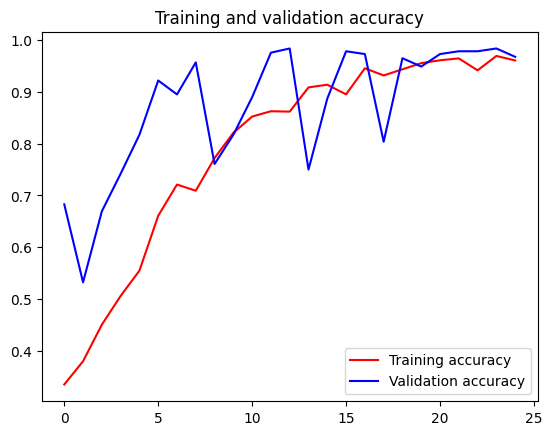

<Figure size 640x480 with 0 Axes>

In [11]:
import matplotlib.pyplot as plt

# Plot the results
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc=0)
plt.figure()

plt.show()

## Save model

In [ ]:
from google.colab import files

model.save("rps.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
import anywidget
import traitlets
import os
import base64
import mimetypes

class FileDownloader(anywidget.AnyWidget):
    """
    An anywidget that renders a button. When clicked, it triggers a server-side
    read of 'file_path' and sends the content to the browser for download.

    The button starts disabled and only enables after a successful handshake
    with the Python kernel, ensuring it doesn't appear active in a dead notebook.
    """

    # The path to the file on the server/local disk that you want to download
    file_path = traitlets.Unicode(help="Path to the file to be downloaded").tag(sync=True)

    # Label for the button
    button_text = traitlets.Unicode("Download File").tag(sync=True)

    _esm = """
    export function render({ model, el }) {
      // Create the button element
      let btn = document.createElement("button");
      btn.classList.add("jupyter-widgets", "jupyter-button", "widget-button");
      btn.style.width = "100%";

      // Initial state: Disabled and waiting
      btn.innerText = "Waiting for Kernel...";
      btn.disabled = true;

      // Update button text if the Python trait changes
      model.on("change:button_text", () => {
        // Only update visually if we are already connected/enabled
        if (!btn.disabled) {
            btn.innerText = model.get("button_text");
        }
      });

      // Handle the click event
      btn.addEventListener("click", () => {
        const filePath = model.get("file_path");

        if (!filePath) {
            alert("No file path set in the Python widget!");
            return;
        }

        // Disable button and show loading state
        const originalText = btn.innerText;
        btn.innerText = "Downloading...";
        btn.disabled = true;

        // Send a request message to the Python backend
        model.send({ type: "request_download" });

        // Helper to restore button state
        const restoreBtn = () => {
            btn.innerText = originalText;
            btn.disabled = false;
        };

        // Timeout safety to restore button if Python doesn't respond within 5s
        setTimeout(restoreBtn, 5000);
      });

      el.appendChild(btn);

      // Listen for messages coming from Python
      model.on("msg:custom", (msg) => {
        if (msg.type === "connection_verified") {
            // HANDSHAKE COMPLETE: Kernel is alive.
            btn.disabled = false;
            btn.innerText = model.get("button_text");
        }
        else if (msg.type === "file_content") {
            // 1. Create a Blob from the Base64 data
            const byteCharacters = atob(msg.content);
            const byteNumbers = new Array(byteCharacters.length);
            for (let i = 0; i < byteCharacters.length; i++) {
                byteNumbers[i] = byteCharacters.charCodeAt(i);
            }
            const byteArray = new Uint8Array(byteNumbers);
            const blob = new Blob([byteArray], { type: msg.mime_type });

            // 2. Create a temporary link to trigger the download
            const url = window.URL.createObjectURL(blob);
            const a = document.createElement("a");
            a.style.display = "none";
            a.href = url;
            a.download = msg.filename;
            document.body.appendChild(a);
            a.click();

            // 3. Cleanup
            window.URL.revokeObjectURL(url);
            document.body.removeChild(a);

            // Restore button text
            btn.innerText = model.get("button_text");
            btn.disabled = false;

        } else if (msg.type === "error") {
            alert(`Error: ${msg.message}`);
            btn.innerText = model.get("button_text");
            btn.disabled = false;
        }
      });

      // INITIATE HANDSHAKE
      // Send a message to Python to check if the kernel is listening.
      // If the kernel is dead (saved notebook), this message goes nowhere,
      // and the button remains disabled.
      setTimeout(() => {
        model.send({ type: "check_connection" });
      }, 500);
    }
    """

    def __init__(self, file_path=None, **kwargs):
        super().__init__(**kwargs)
        if file_path:
            self.file_path = file_path

        # Register the message handler
        self.on_msg(self._handle_custom_msg)

    def _handle_custom_msg(self, msg, content):
        """
        Callback for when the frontend sends a message to Python.
        """
        msg_type = msg.get("type")

        if msg_type == "check_connection":
            # Reply to the frontend to confirm we are alive
            self.send({"type": "connection_verified"})

        elif msg_type == "request_download":
            self._process_download()

    def _process_download(self):
        """
        Reads the file from disk and sends it to the frontend.
        """
        target_path = self.file_path

        # Basic validation
        if not target_path:
            self.send({"type": "error", "message": "File path is not defined."})
            return

        if not os.path.exists(target_path):
            self.send({"type": "error", "message": f"File not found: {target_path}"})
            return

        try:
            # Guess the MIME type so the browser handles it correctly
            mime_type, _ = mimetypes.guess_type(target_path)
            if mime_type is None:
                mime_type = 'application/octet-stream'

            # Read and encode the file
            with open(target_path, "rb") as f:
                file_content = f.read()

            b64_content = base64.b64encode(file_content).decode("utf-8")

            # Send back to JS
            self.send({
                "type": "file_content",
                "filename": os.path.basename(target_path),
                "mime_type": mime_type,
                "content": b64_content
            })

        except Exception as e:
            self.send({"type": "error", "message": str(e)})

dummy_filename = "rps.keras"

FileDownloader(file_path=dummy_filename)

## Load model

In [13]:
!wget "https://github.com/oleksandr-holan/deep-learning/raw/refs/heads/master/lab10/rps.keras"

--2025-12-04 11:51:49--  https://github.com/oleksandr-holan/deep-learning/raw/refs/heads/master/lab10/rps.keras
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/oleksandr-holan/deep-learning/refs/heads/master/lab10/rps.keras [following]
--2025-12-04 11:51:49--  https://raw.githubusercontent.com/oleksandr-holan/deep-learning/refs/heads/master/lab10/rps.keras
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27837927 (27M) [application/octet-stream]
Saving to: ‘rps.keras.3’

rps.keras.3         100%[===================>]  26.55M  --.-KB/s    in 0.1s    

2025-12-04 11:51:50 (239 MB/s) - ‘rps.keras.3’

In [14]:
import tensorflow as tf

# Load the saved model
model = tf.keras.models.load_model("rps.keras")


# Model Prediction

You should be able to upload an image here and have it classified without crashing. This code block will only work in Google Colab, however. You can use your own images or use the ones available [here](https://storage.googleapis.com/learning-datasets/rps-validation.zip)

_**Note:** Old versions of the Safari browser might have compatibility issues with the code block below. If you get an error after you select the images(s) to upload, you can consider updating your browser to the latest version. If not possible, please comment out or skip the code block below, uncomment the next code block and run it._

Знайдено зображень: 33


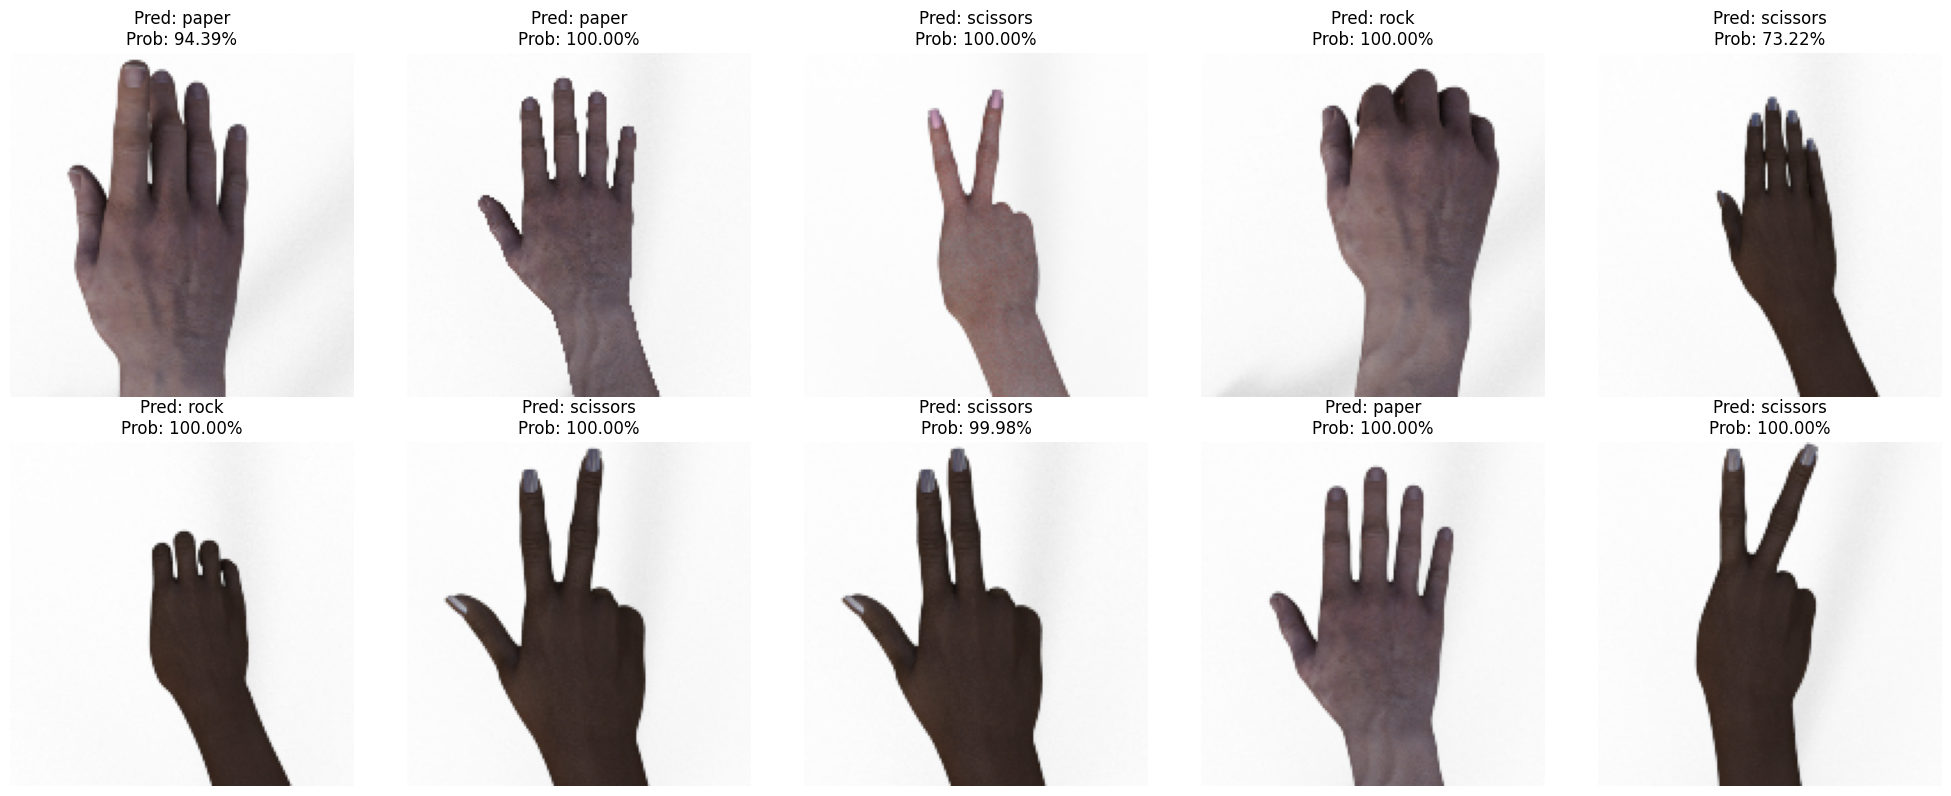

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

val_source_dir = 'tmp/rps-validation'

all_image_paths = []
for root, dirs, files in os.walk(val_source_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_image_paths.append(os.path.join(root, file))

print(f"Знайдено зображень: {len(all_image_paths)}")

if len(all_image_paths) > 0:
    num_images = min(10, len(all_image_paths))
    selected_images = random.sample(all_image_paths, num_images)

    class_names = ['paper', 'rock', 'scissors']

    plt.figure(figsize=(20, 8))

    for i, img_path in enumerate(selected_images):
        img = load_img(img_path, target_size=(150, 150))
        x = img_to_array(img)
        
        x = x / 255.0
        
        x = np.expand_dims(x, axis=0)

        prediction = model.predict(x, verbose=0)
        
        predicted_class_idx = np.argmax(prediction)
        predicted_label = class_names[predicted_class_idx]
        probability = np.max(prediction)

        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.title(f"Pred: {predicted_label}\nProb: {probability:.2%}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Зображення не знайдено. Перевірте, чи правильно розпакувався архів rps-validation.zip")

In [17]:
import ipywidgets as widgets
from IPython.display import display
import os

SAVE_DIR = "uploaded_files"
os.makedirs(SAVE_DIR, exist_ok=True)

uploader_multi = widgets.FileUpload(multiple=True, accept="")

display(uploader_multi)

FileUpload(value={}, description='Upload', multiple=True)

In [9]:
for file in uploader_multi.value.values():
    with open(os.path.join(SAVE_DIR, file["metadata"]["name"]), "wb") as fp:
        fp.write(file["content"])

In [10]:
!ls ./uploaded_files

20251204_101030.jpg  20251204_101042.jpg  20251204_101102.jpg
20251204_101037.jpg  20251204_101056.jpg  20251204_101106.jpg


In [19]:
image_filenames = ["p.1.jpg", "p.2.jpg", "s.1.jpg", "s.2.jpg", "r.1.jpg", "r.2.jpg", "s.3.jpg", "s.4.jpg", "r.3.jpg", "p.3.jpg"]
for i in image_filenames:
    !wget -nc https://raw.githubusercontent.com/oleksandr-holan/deep-learning/refs/heads/master/lab10/test_images/rps/{i} -P ./uploaded_files

File ‘./uploaded_files/p.1.jpg’ already there; not retrieving.

File ‘./uploaded_files/p.2.jpg’ already there; not retrieving.

File ‘./uploaded_files/s.1.jpg’ already there; not retrieving.

File ‘./uploaded_files/s.2.jpg’ already there; not retrieving.

File ‘./uploaded_files/r.1.jpg’ already there; not retrieving.

File ‘./uploaded_files/r.2.jpg’ already there; not retrieving.

File ‘./uploaded_files/s.3.jpg’ already there; not retrieving.

File ‘./uploaded_files/s.4.jpg’ already there; not retrieving.

File ‘./uploaded_files/r.3.jpg’ already there; not retrieving.

File ‘./uploaded_files/p.3.jpg’ already there; not retrieving.



In [18]:
!ls ./uploaded_files/

20251204_101030.jpg  20251204_101106.jpg  p.3.jpg    r.3.jpg	s.3.jpg
20251204_101037.jpg  p.1.jpg		  r.1.jpg    s.1.jpg	s.4.jpg
20251204_101042.jpg  p.1.jpg.1		  r.1.jpg.1  s.1.jpg.1
20251204_101056.jpg  p.2.jpg		  r.2.jpg    s.2.jpg
20251204_101102.jpg  p.2.jpg.1		  r.2.jpg.1  s.2.jpg.1


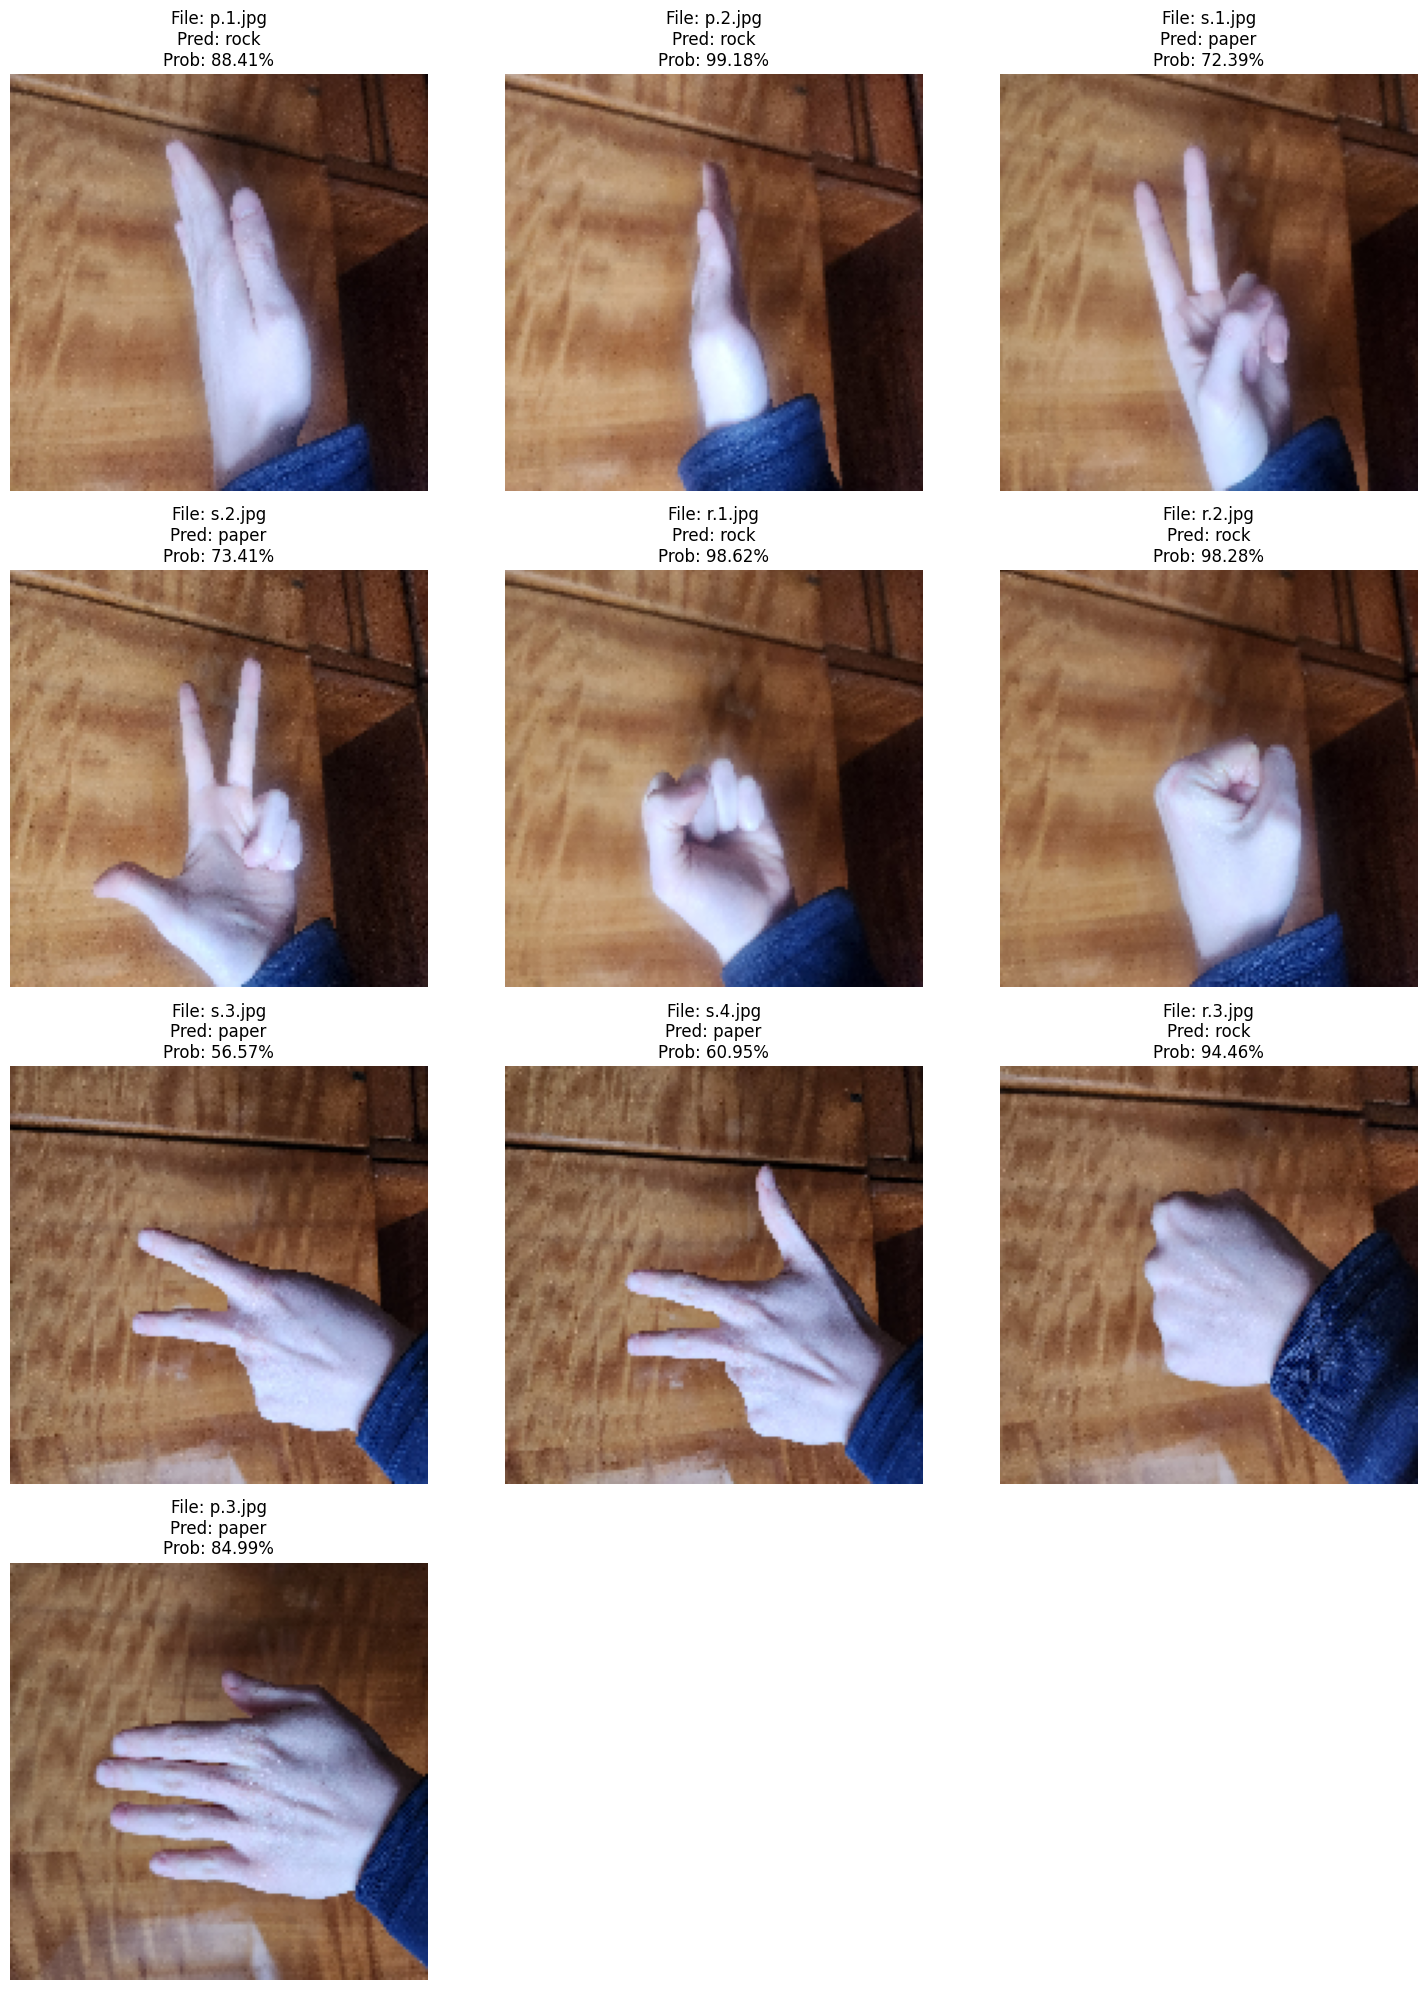

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.utils import load_img, img_to_array

source_dir = "./uploaded_files"

class_names = ["paper", "rock", "scissors"]

num_images = len(image_filenames)
cols = 3
rows = (num_images + cols - 1) // cols

plt.figure(figsize=(15, 5 * rows))

for i, fn in enumerate(image_filenames):
    path = os.path.join(source_dir, fn)

    if os.path.exists(path):
        img = load_img(path, target_size=(150, 150))
        x = img_to_array(img)

        x = x / 255.0

        x = np.expand_dims(x, axis=0)

        prediction = model.predict(x, verbose=0)

        predicted_class_idx = np.argmax(prediction)
        predicted_label = class_names[predicted_class_idx]
        probability = np.max(prediction)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(f"File: {fn}\nPred: {predicted_label}\nProb: {probability:.2%}")
        plt.axis("off")
    else:
        print(f"File not found: {path}")

plt.tight_layout()
plt.show()


## Wrap Up

That concludes this short exercise on the multi-class classifiers. You saw that with just a few changes, you were able to convert your binary classifiers to predict more classes. You used the same techniques for data and model preparation and were able to get relatively good results in just 25 epochs. For practice, you can search for other datasets (e.g. [here](https://archive.ics.uci.edu/datasets)) with more classes and revise the model to accomodate it. Try to experiment with different layers and data augmentation techniques to improve your metrics.